# Library Import

In [129]:
import cv2
import matplotlib.pyplot as plt
import warnings
import pandas as pd
from tensorflow import keras
from keras.src.layers import Rescaling
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import os
from tqdm import tqdm
from sklearn.utils import shuffle
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

Sequential = keras.models.Sequential
Conv2D = keras.layers.Conv2D
Flatten = keras.layers.Flatten
Dropout = keras.layers.Dropout
MaxPooling2D = keras.layers.MaxPooling2D
Dense = keras.layers.Dense
Input = keras.layers.Input
EarlyStopping = keras.callbacks.EarlyStopping
ReduceLROnPlateau = keras.callbacks.ReduceLROnPlateau
Layers = keras.layers
ImageDataGenerator = keras.preprocessing.image.ImageDataGenerator
BatchNormalization = keras.layers.BatchNormalization
CSVLogger = keras.callbacks.CSVLogger
ModelCheckpoint = keras.callbacks.ModelCheckpoint
Adam = keras.optimizers.Adam
l2 = keras.regularizers.l2
TensorBoard = keras.callbacks.TensorBoard

# PATH

In [130]:
train_path = 'dataset/training/'
PLOT_SAVE_DIR = 'output/plot/v3/'
LOG_DIR = 'output/log/v3/'
MODEL_SAVE_PATH = 'output/model/v3/cnn_model_v3.keras'
HISTORY_PATH = 'output/model/v3/train_history_v3.npy'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

LABEL_MAPPING = {
    'alcohol': 0,
    'blood': 1,
    'sexual': 2,
    'traffic_accident': 3
}

class_names = ['alcohol', 'blood', 'sexual', 'traffic_accident']
nb_classes = len(class_names)

# Function to load data

In [131]:
def load_data(dataset):
    images = []
    labels = []

    if isinstance(dataset, str):
        dataset = [dataset]

    for dataset_path in dataset:
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Dataset directory {dataset_path} not found.")

        for folder in os.listdir(dataset_path):
            if folder in LABEL_MAPPING:
                label = LABEL_MAPPING[folder]
            else:
                continue

            folder_path = os.path.join(dataset_path, folder)

            if not os.path.isdir(folder_path):
                continue

            for file in tqdm(os.listdir(folder_path)):
                img_path = os.path.join(folder_path, file)

                if not os.path.isfile(img_path):
                    continue

                image = cv2.imread(img_path)

                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int')

    return images, labels

# Execute images and labels

In [132]:
images, labels = load_data(train_path)

100%|██████████| 500/500 [00:01<00:00, 392.97it/s]


In [133]:
reverse_label_mapping = {v: k for k, v in LABEL_MAPPING.items()}
class_label_names = [reverse_label_mapping[label] for label in labels]

fig = px.histogram(
    y=class_label_names,
    template='plotly_dark',
    color=class_label_names,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'}
)
fig.show()

# Split data into training and testing sets (80% train, 20% test)

In [134]:
images, labels = shuffle(images, labels, random_state=10)

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2)
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size=0.5)

In [135]:
n_train = train_labels.shape[0]
n_val = val_labels.shape[0]
n_test = test_labels.shape[0]

print("Number of training examples: {}".format(n_train))
print("Number of validation examples: {}".format(n_val))
print("Number of testing examples: {}".format(n_test))

print("Training images are of shape: {}".format(train_images.shape))
print("Training labels are of shape: {}".format(train_labels.shape))
print("Validation images are of shape: {}".format(val_images.shape))
print("Validation labels are of shape: {}".format(val_labels.shape))
print("Test images are of shape: {}".format(test_images.shape))
print("Test labels are of shape: {}".format(test_labels.shape))

Number of training examples: 1600
Number of validation examples: 200
Number of testing examples: 200
Training images are of shape: (1600, 224, 224)
Training labels are of shape: (1600,)
Validation images are of shape: (200, 224, 224)
Validation labels are of shape: (200,)
Test images are of shape: (200, 224, 224)
Test labels are of shape: (200,)


# Visualize dataset

In [136]:
_, train_counts = np.unique(train_labels, return_counts=True)
_, val_counts = np.unique(val_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=class_names,
    y=train_counts,
    name='Train',
    marker=dict(color='blue')
))

fig.add_trace(go.Bar(
    x=class_names,
    y=val_counts,
    name='Validation',
    marker=dict(color='green')
))

fig.add_trace(go.Bar(
    x=class_names,
    y=test_counts,
    name='Test',
    marker=dict(color='red')
))

fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark"
)

# Show the plot
fig.show()

In [137]:
fig = go.Figure(data=[go.Pie(
    labels=class_names,
    values=train_counts,
    textinfo='percent+label',
    marker=dict(colors=['blue', 'green', 'red', 'purple']),
)])

fig.update_layout(
    title="Proportion of Each Classes",
    template="plotly_dark",
)

fig.show()

# Data Augmentation

In [138]:
train_images = np.expand_dims(train_images, axis=-1)
val_images = np.expand_dims(val_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE)


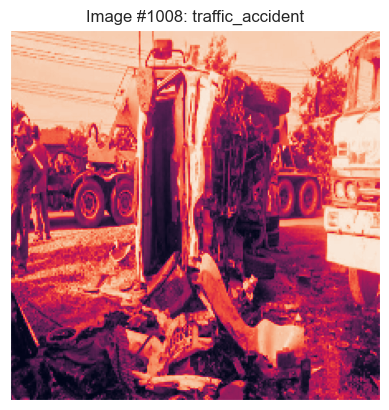

In [139]:
def display_random_image(class_names, images, labels):
    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{}: '.format(index) + class_names[labels[index]])
    plt.show()


display_random_image(class_names, train_images, train_labels)

# Display some dataset

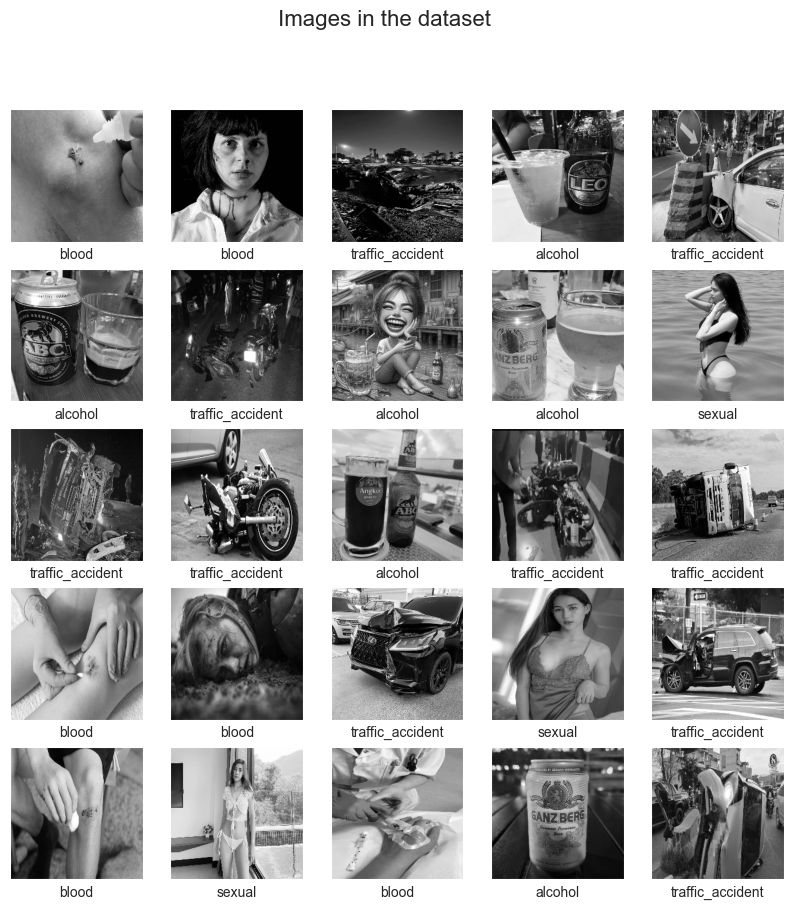

In [140]:
def display_dataset(class_names, images, labels):
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle("Images in the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap='gray')
        plt.xlabel(class_names[labels[i]])
    plt.show()


display_dataset(class_names, train_images, train_labels)

# Model architecture

In [141]:
# Model architecture
model = Sequential()

# Normalization layer
model.add(Rescaling(1. / 255, input_shape=(224, 224, 1)))

# First convolutional block
model.add(Conv2D(32, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Second convolutional block
model.add(Conv2D(64, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Third convolutional block
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Fourth convolutional block
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Flatten
model.add(Flatten())

# Fully connected layers 
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

# Output layer 
model.add(Dense(units=nb_classes, activation='softmax'))

# summary
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 220, 220, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 106, 106, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 23, 23, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 23, 23, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │    15,860,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,349,444 (62.37 MB)

 Trainable params: 16,348,484 (62.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [142]:
train_steps = len(train_images) // BATCH_SIZE
validate_steps = len(val_images) // BATCH_SIZE
test_steps = len(test_images) // BATCH_SIZE

print(f"training_steps: {train_steps}")
print(f"validation_steps: {validate_steps}")
print(f"testing_steps: {test_steps}")

training_steps: 50
validation_steps: 6
testing_steps: 6


# Compile the model

In [143]:
# Compile
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
callbacks = [
    CSVLogger(os.path.join(LOG_DIR, 'training_log_v3.csv'), append=True),
    TensorBoard(log_dir=os.path.join(LOG_DIR, "tensorboard_logs"))
]

# Train
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=EPOCHS,
    validation_data=valid_generator,
    validation_steps=validate_steps,
    callbacks=callbacks,
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.2813 - loss: 19.1321 - val_accuracy: 0.2240 - val_loss: 30.2966
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.1250 - val_loss: 31.6727
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.3358 - loss: 14.6317 - val_accuracy: 0.2083 - val_loss: 23.1118
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 18.8126
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.3603 - loss: 10.5243 - val_accuracy: 0.2240 - val_loss: 18.0280
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.1250 - val_loss: 20.3693
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.4018 - loss: 7.4186 - val_accuracy: 0.2188 - val_loss: 11.1871
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0

# Saved model

In [154]:
model.save(MODEL_SAVE_PATH)
np.save(HISTORY_PATH, history.history)

# Visualize and testing

In [144]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_steps)
print(f"Test accuracy: {test_acc * 100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.2174 - loss: 18.7695
Test accuracy: 23.44%


In [145]:
train_loss, train_accuracy = model.evaluate(train_generator, steps=train_steps)
print(f'Train accuracy: {train_accuracy * 100:.2f}%')

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.2640 - loss: 18.2590
Train accuracy: 25.06%


# Evaluate the model

In [146]:
def plot_accuracy_loss_chart(history):
    epochs = [i for i in range(len(history.history['accuracy']))]
    fig, ax = plt.subplots(1, 2)
    train_acc = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    fig.set_size_inches(20, 10)

    ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
    ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    ax[0].set_title('Training & Validation Accuracy')
    ax[0].legend()
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")

    ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax[1].set_title('Training & Validation Loss')
    ax[1].legend()
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Training & Validation Loss")

    plt.show()

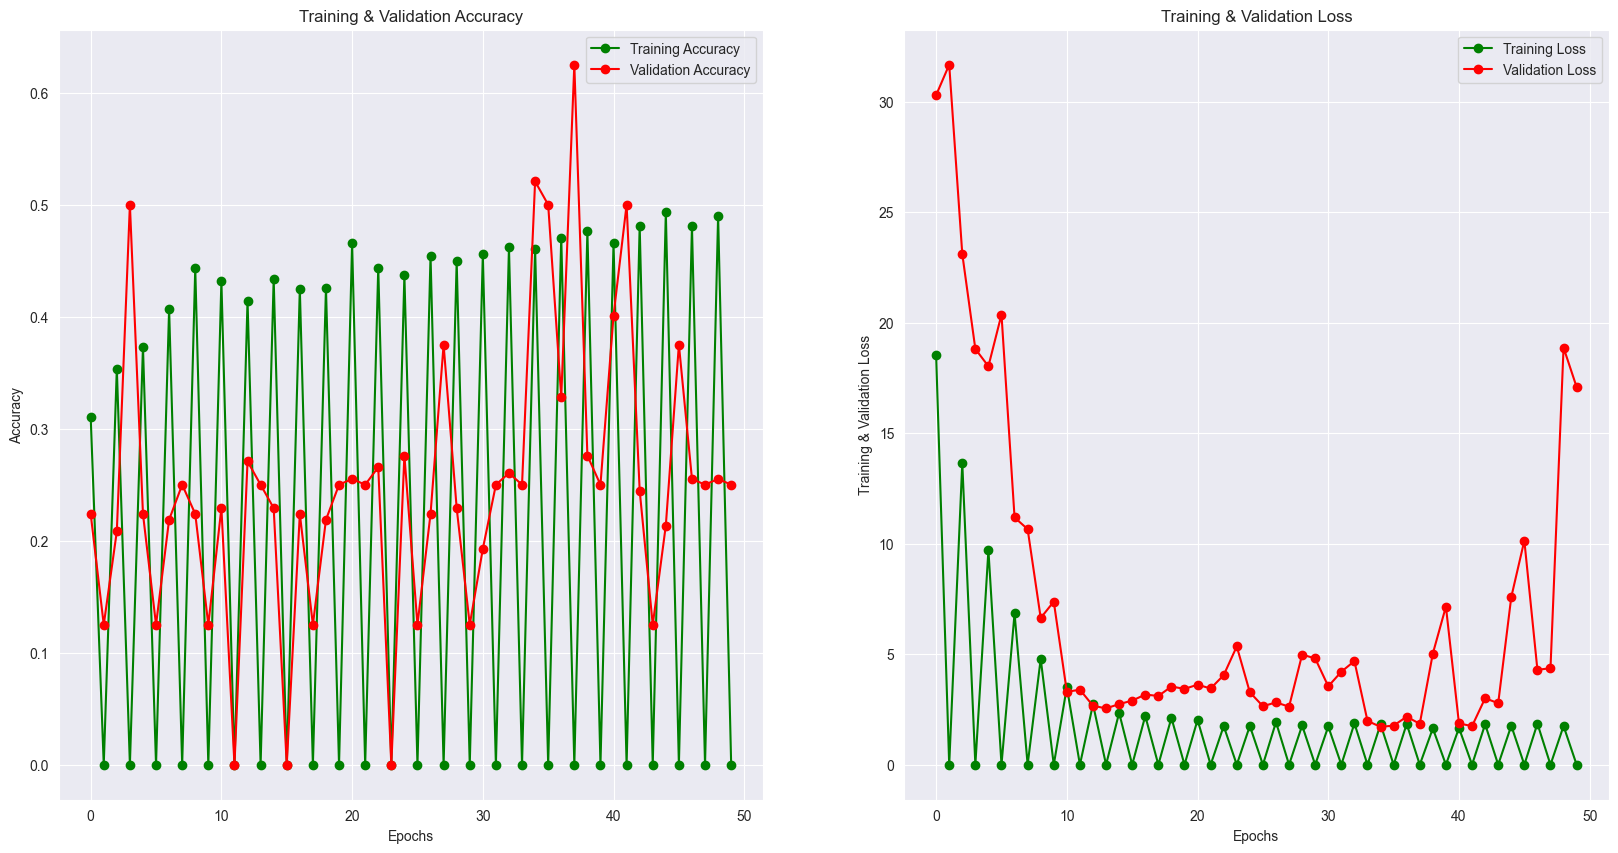

In [147]:
plot_accuracy_loss_chart(history)

In [155]:
results = model.evaluate(test_images, test_labels)

print("Loss of the model is: ", results[0])
print("Accuracy of the model is: ", results[1] * 100, "%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step - accuracy: 0.2597 - loss: 5514.7031
Loss of the model is:  5528.68701171875
Accuracy of the model is:  23.999999463558197 %


In [156]:
predictions = model.predict(test_images)
predictions = np.argmax(predictions, axis=1)
predictions[:15]

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [150]:
print(classification_report(
    test_labels,
    predictions,
    target_names=['alcohol (Class 0)', 'blood (Class 1)', 'sexual (Class 2)', 'traffic_accident (Class 3)']))

                            precision    recall  f1-score   support

         alcohol (Class 0)       0.00      0.00      0.00        49
           blood (Class 1)       0.00      0.00      0.00        52
          sexual (Class 2)       0.24      1.00      0.39        48
traffic_accident (Class 3)       0.00      0.00      0.00        51

                  accuracy                           0.24       200
                 macro avg       0.06      0.25      0.10       200
              weighted avg       0.06      0.24      0.09       200



In [151]:
cm = confusion_matrix(test_labels, predictions)
cm = pd.DataFrame(cm, index=['0', '1', '2', '3'], columns=['0', '1', '2', '3'])
cm

,0,1,2,3
0,0,0,49,0
1,0,0,52,0
2,0,0,48,0
3,0,0,51,0


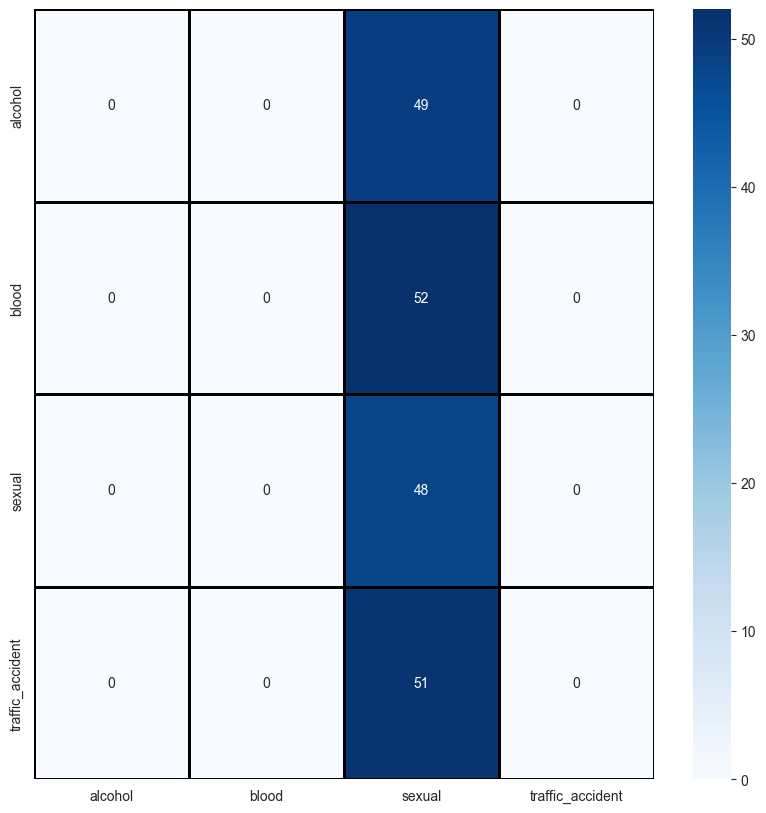

In [152]:
def plot_confusion_matrix(cm):
    plt.figure(figsize=(10, 10))
    sns.heatmap(
        cm,
        cmap='Blues',
        linecolor='black',
        linewidth=1,
        annot=True,
        fmt='',
        xticklabels=class_names,
        yticklabels=class_names)


plot_confusion_matrix(cm)

# Visualizing Feature Maps

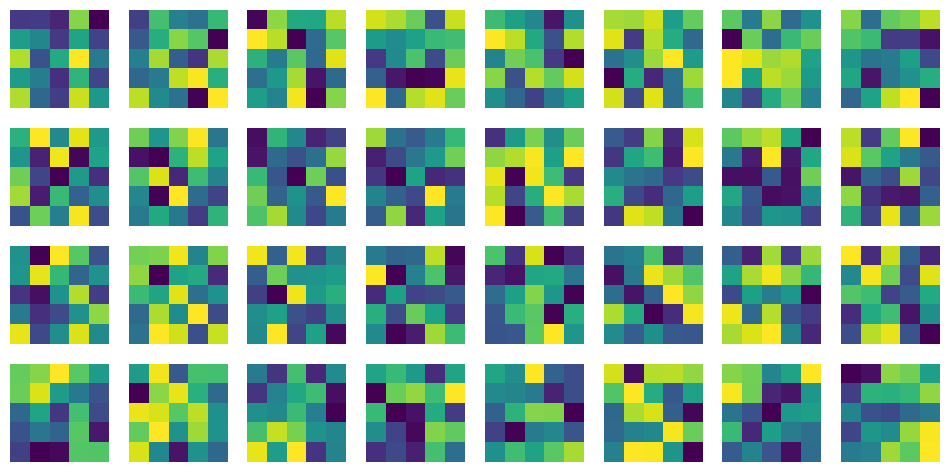

In [153]:
filters, biases = model.layers[1].get_weights()

filters_min = filters.min()
filters_max = filters.max()
filters = (filters - filters_min) / (filters_max - filters_min)

n_filters = filters.shape[-1]
plt.figure(figsize=(12, 12))
for i in range(n_filters):
    plt.subplot(8, 8, i + 1)
    plt.imshow(filters[:, :, 0, i], cmap='viridis')
    plt.axis('off')
plt.show()